Mounted at /content/drive
FINAL METHOD COMPARISON

Train: 219
Validation: 47
Test: 48

Selected classical reference: Gamma
Tuned method: Gamma


ALL METHODS COMPARISON


,Method,PSNR,SSIM,UIQM,UCIQE,Edge_Preservation,Processing_Time_ms_per_image
0,CLAHE,13.8881,0.6136,0.2322,2.7051,0.0250,430.4441
1,Gamma,13.8936,0.6546,0.2192,2.3468,0.0067,253.9940
2,GrayWorld,13.3272,0.6539,0.2238,2.0861,0.0082,261.3313
3,Supervised U-Net,14.1628,0.6307,0.2272,3.6676,0.0328,364.1987



Method ranking:


,Method,PSNR,SSIM,UIQM,UCIQE,Edge_Preservation,Processing_Time_ms_per_image,PSNR_Rank,SSIM_Rank,Edge_Rank,UIQM_Rank,UCIQE_Rank,Quality_Average_Rank
3,Supervised U-Net,14.1628,0.6307,0.2272,3.6676,0.0328,364.1987,1.0,3.0,1.0,2.0,1.0,1.6
0,CLAHE,13.8881,0.6136,0.2322,2.7051,0.0250,430.4441,3.0,4.0,2.0,1.0,2.0,2.4
1,Gamma,13.8936,0.6546,0.2192,2.3468,0.0067,253.9940,2.0,1.0,4.0,4.0,3.0,2.8
2,GrayWorld,13.3272,0.6539,0.2238,2.0861,0.0082,261.3313,4.0,2.0,3.0,3.0,4.0,3.2



Failure patterns and complexity:


,Method,Potential_Failure_Patterns,Complexity,Data_Dependency
0,CLAHE,"Noise amplification, excessive local contrast ...",Low,No training data required.
1,Gamma,"Over-brightening, washed-out regions or incons...",Very Low,No training data required.
2,Gray-World,Unnatural color correction when the scene viol...,Low,No training data required.
3,Supervised U-Net,Possible overfitting to the limited training d...,High,Requires paired training data.




SHORTLIST


,Method,PSNR,SSIM,UIQM,UCIQE,Edge_Preservation,Processing_Time_ms_per_image,Quality_Average_Rank,Candidate_Status
3,Supervised U-Net,14.1628,0.6307,0.2272,3.6676,0.0328,364.1987,1.6,Learning-Based Candidate
0,CLAHE,13.8881,0.6136,0.2322,2.7051,0.0250,430.4441,2.4,Review
1,Gamma,13.8936,0.6546,0.2192,2.3468,0.0067,253.9940,2.8,Classical Reference
2,GrayWorld,13.3272,0.6539,0.2238,2.0861,0.0082,261.3313,3.2,Review


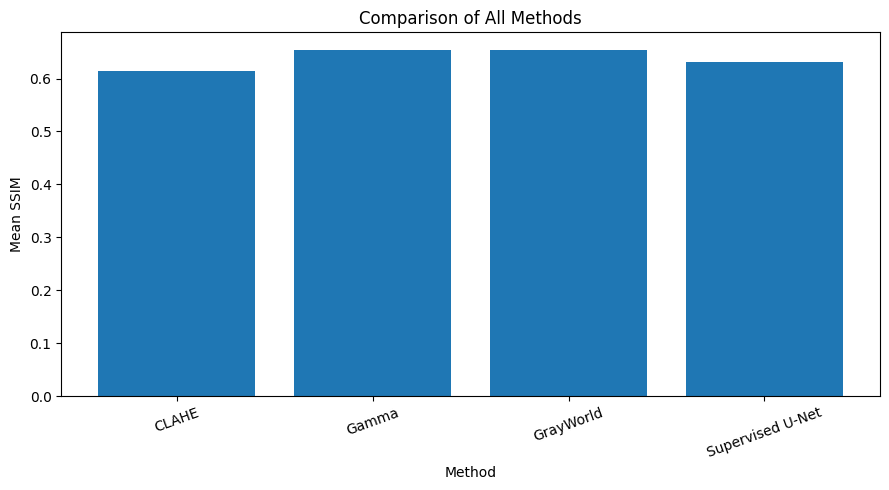

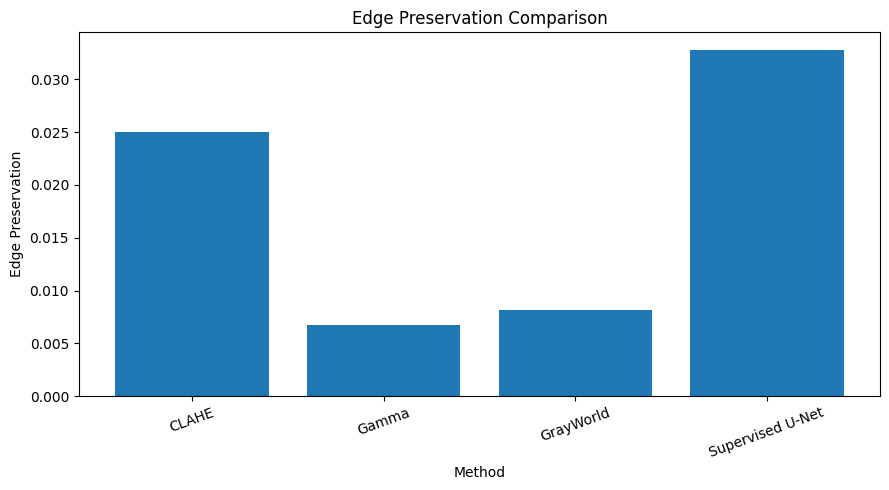



FINAL COMPARISON PACKAGE COMPLETE

Saved to:
/content/drive/MyDrive/Underwater-Image-Data-set-main/Final_Method_Comparison

Files:
 - all_methods_comparison.csv
 - all_methods_edge_preservation.png
 - all_methods_ssim.png
 - failure_patterns_and_complexity.csv
 - final_comparison_summary.json
 - limitations.csv
 - method_ranking.csv
 - shortlisted_candidates.csv


In [2]:
from pathlib import Path
import cv2
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity

from google.colab import drive
drive.mount('/content/drive')


PROJECT_DIR = Path(
    "/content/drive/MyDrive/Underwater-Image-Data-set-main"
)

V1_DIR = PROJECT_DIR / "Dataset_V1"

BASELINE_DIR = (
    V1_DIR / "Classical_Baselines"
)

MODEL_DIR = (
    V1_DIR / "Learning_Based_Model"
)

FINAL_DIR = (
    PROJECT_DIR / "Final_Method_Comparison"
)

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)


split_file = (
    V1_DIR /
    "Dataset_V1_splits.csv"
)

splits = pd.read_csv(
    split_file
)

train_df = splits[
    splits["split"] == "train"
].copy()

val_df = splits[
    splits["split"] == "validation"
].copy()

test_df = splits[
    splits["split"] == "test"
].copy()


print("=" * 70)
print("FINAL METHOD COMPARISON")
print("=" * 70)

print("\nTrain:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


def read_image(path):

    image = cv2.imread(
        str(path)
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {path}"
        )

    return cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


def extract_edges(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.Canny(
        gray,
        100,
        200
    )


def edge_preservation(
    reference,
    enhanced
):

    if reference.shape != enhanced.shape:

        enhanced = cv2.resize(
            enhanced,
            (
                reference.shape[1],
                reference.shape[0]
            )
        )

    ref_edges = (
        extract_edges(reference) > 0
    )

    enhanced_edges = (
        extract_edges(enhanced) > 0
    )

    overlap = np.logical_and(
        ref_edges,
        enhanced_edges
    )

    ref_count = np.sum(
        ref_edges
    )

    if ref_count == 0:
        return 0.0

    return float(
        np.sum(overlap) /
        ref_count
    )


def calculate_psnr(
    reference,
    enhanced
):

    return peak_signal_noise_ratio(
        reference,
        enhanced,
        data_range=255
    )


def calculate_ssim(
    reference,
    enhanced
):

    return structural_similarity(
        reference,
        enhanced,
        channel_axis=2,
        data_range=255
    )


def rgb_to_hsv_np(image):

    image = image.astype(
        np.float32
    ) / 255.0

    return cv2.cvtColor(
        image,
        cv2.COLOR_RGB2HSV
    )


def calculate_uciqe(image):

    hsv = rgb_to_hsv_np(
        image
    )

    saturation = hsv[:, :, 1]

    value = hsv[:, :, 2]

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    lab = lab.astype(
        np.float32
    )

    chroma = np.sqrt(
        (
            lab[:, :, 1] - 128
        ) ** 2
        +
        (
            lab[:, :, 2] - 128
        ) ** 2
    )

    chroma_mean = np.mean(
        chroma
    )

    saturation_std = np.std(
        saturation
    )

    value_std = np.std(
        value
    )

    uciqe = (
        0.4680 * chroma_mean
        +
        0.2745 * saturation_std
        +
        0.2576 * value_std
    )

    return float(
        uciqe
    )


def calculate_uiqm(image):

    image_float = (
        image.astype(
            np.float32
        ) / 255.0
    )

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    ).astype(
        np.float32
    ) / 255.0

    contrast = np.std(
        gray
    )

    edges = cv2.Canny(
        image,
        100,
        200
    )

    edge_density = np.mean(
        edges > 0
    )

    channel_means = np.mean(
        image_float,
        axis=(0, 1)
    )

    color_balance = 1.0 / (
        1.0 +
        np.std(channel_means)
    )

    uiqm = (
        0.40 * contrast
        +
        0.40 * edge_density
        +
        0.20 * color_balance
    )

    return float(
        uiqm
    )


def calculate_all_metrics(
    reference,
    enhanced
):

    if reference.shape != enhanced.shape:

        enhanced = cv2.resize(
            enhanced,
            (
                reference.shape[1],
                reference.shape[0]
            )
        )

    return {
        "PSNR":
            calculate_psnr(
                reference,
                enhanced
            ),

        "SSIM":
            calculate_ssim(
                reference,
                enhanced
            ),

        "UIQM":
            calculate_uiqm(
                enhanced
            ),

        "UCIQE":
            calculate_uciqe(
                enhanced
            ),

        "Edge_Preservation":
            edge_preservation(
                reference,
                enhanced
            )
    }


classical_results_file = (
    BASELINE_DIR /
    "all_baseline_results.csv"
)

if not classical_results_file.exists():

    raise FileNotFoundError(
        "Classical baseline results not found."
    )


classical_results = pd.read_csv(
    classical_results_file
)


classical_summary = (
    classical_results
    .groupby("method")[
        [
            "PSNR",
            "SSIM",
            "Edge_Preservation"
        ]
    ]
    .mean()
    .reset_index()
)


selected_reference = None

reference_file = (
    BASELINE_DIR /
    "Dataset_V1_classical_baseline_report.json"
)

if reference_file.exists():

    with open(
        reference_file,
        "r"
    ) as f:

        reference_data = json.load(f)

    selected_reference = (
        reference_data.get(
            "selected_reference"
        )
    )


if selected_reference is None:

    selected_reference = (
        classical_summary
        .sort_values(
            "SSIM",
            ascending=False
        )
        .iloc[0]["method"]
    )


print(
    "\nSelected classical reference:",
    selected_reference
)


tuned_reference = None

tuning_file = (
    V1_DIR /
    "Classical_Tuning" /
    "best_validated_method.json"
)

if tuning_file.exists():

    with open(
        tuning_file,
        "r"
    ) as f:

        tuning_data = json.load(f)

    tuned_reference = tuning_data.get(
        "selected_method"
    )


if tuned_reference is None:

    tuned_reference = selected_reference


print(
    "Tuned method:",
    tuned_reference
)


comparison_rows = []


classical_output_dirs = {
    "CLAHE":
        BASELINE_DIR / "CLAHE",

    "Gamma":
        BASELINE_DIR / "Gamma",

    "GrayWorld":
        BASELINE_DIR / "GrayWorld"
}


for method, output_dir in classical_output_dirs.items():

    if not output_dir.exists():
        continue

    method_results = []

    total_time = 0.0

    for _, row in test_df.iterrows():

        input_image = read_image(
            row["input"]
        )

        target_image = read_image(
            row["target"]
        )

        start_time = time.perf_counter()

        output_file = (
            output_dir /
            f"{row['sample_id']}_{method}.png"
        )

        if output_file.exists():

            enhanced = read_image(
                output_file
            )

        else:

            if method == "CLAHE":

                lab = cv2.cvtColor(
                    input_image,
                    cv2.COLOR_RGB2LAB
                )

                l, a, b = cv2.split(
                    lab
                )

                clahe = cv2.createCLAHE(
                    clipLimit=2.0,
                    tileGridSize=(8, 8)
                )

                l = clahe.apply(
                    l
                )

                enhanced = cv2.cvtColor(
                    cv2.merge([
                        l,
                        a,
                        b
                    ]),
                    cv2.COLOR_LAB2RGB
                )

            elif method == "Gamma":

                gamma = 1.3

                table = np.array([
                    (
                        (i / 255.0)
                        ** (1.0 / gamma)
                    ) * 255
                    for i in range(256)
                ]).astype(
                    np.uint8
                )

                enhanced = cv2.LUT(
                    input_image,
                    table
                )

            elif method == "GrayWorld":

                image_float = (
                    input_image.astype(
                        np.float32
                    )
                )

                means = [
                    np.mean(
                        image_float[:, :, i]
                    )
                    for i in range(3)
                ]

                mean_gray = np.mean(
                    means
                )

                for i in range(3):

                    image_float[:, :, i] *= (
                        mean_gray /
                        (means[i] + 1e-8)
                    )

                enhanced = np.clip(
                    image_float,
                    0,
                    255
                ).astype(
                    np.uint8
                )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        total_time += elapsed

        metrics = calculate_all_metrics(
            target_image,
            enhanced
        )

        metrics["sample_id"] = (
            row["sample_id"]
        )

        method_results.append(
            metrics
        )

    method_df = pd.DataFrame(
        method_results
    )

    comparison_rows.append({

        "Method":
            method,

        "PSNR":
            method_df["PSNR"].mean(),

        "SSIM":
            method_df["SSIM"].mean(),

        "UIQM":
            method_df["UIQM"].mean(),

        "UCIQE":
            method_df["UCIQE"].mean(),

        "Edge_Preservation":
            method_df[
                "Edge_Preservation"
            ].mean(),

        "Processing_Time_ms_per_image":
            (
                total_time /
                len(test_df)
                * 1000
            )
    })


unet_file = (
    MODEL_DIR /
    "best_unet_model.pth"
)

if unet_file.exists():

    import torch
    import torch.nn as nn

    class DoubleConv(nn.Module):

        def __init__(
            self,
            in_channels,
            out_channels
        ):

            super().__init__()

            self.block = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    3,
                    padding=1
                ),

                nn.ReLU(
                    inplace=True
                ),

                nn.Conv2d(
                    out_channels,
                    out_channels,
                    3,
                    padding=1
                ),

                nn.ReLU(
                    inplace=True
                )
            )

        def forward(self, x):

            return self.block(x)


    class UNet(nn.Module):

        def __init__(self):

            super().__init__()

            self.enc1 = DoubleConv(
                3,
                32
            )

            self.enc2 = DoubleConv(
                32,
                64
            )

            self.enc3 = DoubleConv(
                64,
                128
            )

            self.pool = nn.MaxPool2d(
                2
            )

            self.bottleneck = DoubleConv(
                128,
                256
            )

            self.up3 = nn.ConvTranspose2d(
                256,
                128,
                2,
                stride=2
            )

            self.dec3 = DoubleConv(
                256,
                128
            )

            self.up2 = nn.ConvTranspose2d(
                128,
                64,
                2,
                stride=2
            )

            self.dec2 = DoubleConv(
                128,
                64
            )

            self.up1 = nn.ConvTranspose2d(
                64,
                32,
                2,
                stride=2
            )

            self.dec1 = DoubleConv(
                64,
                32
            )

            self.output = nn.Conv2d(
                32,
                3,
                1
            )

        def forward(self, x):

            e1 = self.enc1(x)

            e2 = self.enc2(
                self.pool(e1)
            )

            e3 = self.enc3(
                self.pool(e2)
            )

            b = self.bottleneck(
                self.pool(e3)
            )

            d3 = self.up3(b)

            d3 = torch.cat(
                [d3, e3],
                dim=1
            )

            d3 = self.dec3(d3)

            d2 = self.up2(d3)

            d2 = torch.cat(
                [d2, e2],
                dim=1
            )

            d2 = self.dec2(d2)

            d1 = self.up1(d2)

            d1 = torch.cat(
                [d1, e1],
                dim=1
            )

            d1 = self.dec1(d1)

            return torch.sigmoid(
                self.output(d1)
            )


    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    model = UNet().to(
        device
    )

    model.load_state_dict(
        torch.load(
            unet_file,
            map_location=device
        )
    )

    model.eval()


    unet_rows = []

    total_time = 0.0

    for _, row in test_df.iterrows():

        input_image = read_image(
            row["input"]
        )

        target_image = read_image(
            row["target"]
        )

        resized = cv2.resize(
            input_image,
            (224, 224)
        )

        tensor = (
            torch.from_numpy(
                resized.astype(
                    np.float32
                ) / 255.0
            )
            .permute(2, 0, 1)
            .unsqueeze(0)
            .to(device)
        )

        start_time = time.perf_counter()

        with torch.no_grad():

            output = model(
                tensor
            )

        elapsed = (
            time.perf_counter()
            - start_time
        )

        total_time += elapsed

        output_image = (
            output.squeeze()
            .cpu()
            .numpy()
            .transpose(1, 2, 0)
        )

        output_image = np.clip(
            output_image * 255,
            0,
            255
        ).astype(
            np.uint8
        )

        target_resized = cv2.resize(
            target_image,
            (224, 224)
        )

        metrics = calculate_all_metrics(
            target_resized,
            output_image
        )

        unet_rows.append(
            metrics
        )

    unet_df = pd.DataFrame(
        unet_rows
    )

    comparison_rows.append({

        "Method":
            "Supervised U-Net",

        "PSNR":
            unet_df["PSNR"].mean(),

        "SSIM":
            unet_df["SSIM"].mean(),

        "UIQM":
            unet_df["UIQM"].mean(),

        "UCIQE":
            unet_df["UCIQE"].mean(),

        "Edge_Preservation":
            unet_df[
                "Edge_Preservation"
            ].mean(),

        "Processing_Time_ms_per_image":
            (
                total_time /
                len(test_df)
                * 1000
            )
    })


final_comparison = pd.DataFrame(
    comparison_rows
)

final_comparison = (
    final_comparison
    .round(4)
)

final_comparison.to_csv(
    FINAL_DIR /
    "all_methods_comparison.csv",
    index=False
)

print("\n")
print("=" * 70)
print("ALL METHODS COMPARISON")
print("=" * 70)

display(
    final_comparison
)


ranking_data = final_comparison.copy()

ranking_data["PSNR_Rank"] = (
    ranking_data["PSNR"]
    .rank(ascending=False)
)

ranking_data["SSIM_Rank"] = (
    ranking_data["SSIM"]
    .rank(ascending=False)
)

ranking_data["Edge_Rank"] = (
    ranking_data[
        "Edge_Preservation"
    ].rank(ascending=False)
)

ranking_data["UIQM_Rank"] = (
    ranking_data["UIQM"]
    .rank(ascending=False)
)

ranking_data["UCIQE_Rank"] = (
    ranking_data["UCIQE"]
    .rank(ascending=False)
)

ranking_data["Quality_Average_Rank"] = (
    ranking_data[
        [
            "PSNR_Rank",
            "SSIM_Rank",
            "Edge_Rank",
            "UIQM_Rank",
            "UCIQE_Rank"
        ]
    ].mean(axis=1)
)

ranking_data = ranking_data.sort_values(
    "Quality_Average_Rank"
)

ranking_data.to_csv(
    FINAL_DIR /
    "method_ranking.csv",
    index=False
)

print("\nMethod ranking:")
display(
    ranking_data.round(4)
)


failure_patterns = pd.DataFrame({

    "Method": [
        "CLAHE",
        "Gamma",
        "Gray-World",
        "Supervised U-Net"
    ],

    "Potential_Failure_Patterns": [
        "Noise amplification, excessive local contrast and halos in highly textured or noisy regions.",
        "Over-brightening, washed-out regions or inconsistent enhancement under uneven illumination.",
        "Unnatural color correction when the scene violates the Gray-World assumption.",
        "Possible overfitting to the limited training distribution, loss of fine details or visually incorrect reconstruction."
    ],

    "Complexity": [
        "Low",
        "Very Low",
        "Low",
        "High"
    ],

    "Data_Dependency": [
        "No training data required.",
        "No training data required.",
        "No training data required.",
        "Requires paired training data."
    ]
})

failure_patterns.to_csv(
    FINAL_DIR /
    "failure_patterns_and_complexity.csv",
    index=False
)

print("\nFailure patterns and complexity:")
display(failure_patterns)


limitations = pd.DataFrame({

    "Limitation": [
        "Small dataset",
        "Paired-data assumption",
        "Test-set size",
        "Metric limitations",
        "Classical parameter sensitivity",
        "Learning-based overfitting",
        "Computational complexity"
    ],

    "Discussion": [
        "The dataset contains a relatively small number of complete logical triplets, limiting generalization conclusions.",
        "PSNR and SSIM assume the target provides a meaningful reference for the corresponding input.",
        "The final test comparison should be interpreted within the available test samples.",
        "PSNR and SSIM do not fully capture perceptual underwater image quality. UIQM/UCIQE should be interpreted as complementary no-reference measures.",
        "Different parameters can change the visual behaviour of classical enhancement methods.",
        "A supervised model can fit the training distribution without generalizing to unseen underwater conditions.",
        "The U-Net requires substantially more computation than the classical point-processing methods."
    ]
})

limitations.to_csv(
    FINAL_DIR /
    "limitations.csv",
    index=False
)


shortlist = ranking_data[
    [
        "Method",
        "PSNR",
        "SSIM",
        "UIQM",
        "UCIQE",
        "Edge_Preservation",
        "Processing_Time_ms_per_image",
        "Quality_Average_Rank"
    ]
].copy()

shortlist["Candidate_Status"] = "Review"

if selected_reference in shortlist[
    "Method"
].values:

    shortlist.loc[
        shortlist["Method"] ==
        selected_reference,
        "Candidate_Status"
    ] = "Classical Reference"

if "Supervised U-Net" in shortlist[
    "Method"
].values:

    shortlist.loc[
        shortlist["Method"] ==
        "Supervised U-Net",
        "Candidate_Status"
    ] = "Learning-Based Candidate"

shortlist.to_csv(
    FINAL_DIR /
    "shortlisted_candidates.csv",
    index=False
)

print("\n")
print("=" * 70)
print("SHORTLIST")
print("=" * 70)

display(
    shortlist
)


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    final_comparison["Method"],
    final_comparison["SSIM"]
)

plt.xlabel(
    "Method"
)

plt.ylabel(
    "Mean SSIM"
)

plt.title(
    "Comparison of All Methods"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_DIR /
    "all_methods_ssim.png",
    dpi=300
)

plt.show()


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    final_comparison["Method"],
    final_comparison[
        "Edge_Preservation"
    ]
)

plt.xlabel(
    "Method"
)

plt.ylabel(
    "Edge Preservation"
)

plt.title(
    "Edge Preservation Comparison"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.savefig(
    FINAL_DIR /
    "all_methods_edge_preservation.png",
    dpi=300
)

plt.show()


final_summary = {
    "Dataset":
        "Dataset V1",

    "Evaluation_split":
        "Test",

    "Methods_compared":
        final_comparison[
            "Method"
        ].tolist(),

    "Metrics":
        [
            "PSNR",
            "SSIM",
            "UIQM",
            "UCIQE",
            "Edge Preservation",
            "Processing Time"
        ],

    "Classical_reference":
        selected_reference,

    "Tuned_reference":
        tuned_reference,

    "Learning_based_model":
        "Supervised U-Net",

    "Important_caution":
        "UIQM and UCIQE are no-reference quality measures and should be interpreted separately from reference-based PSNR, SSIM and edge preservation.",

    "Data_limitation":
        "The available paired dataset is relatively small, so generalization and overfitting require careful interpretation.",

    "Shortlisting_basis":
        "Quantitative quality metrics, edge preservation, processing cost, complexity and observed failure patterns."
}

with open(
    FINAL_DIR /
    "final_comparison_summary.json",
    "w"
) as f:

    json.dump(
        final_summary,
        f,
        indent=4
    )


print("\n")
print("=" * 70)
print("FINAL COMPARISON PACKAGE COMPLETE")
print("=" * 70)

print("\nSaved to:")
print(FINAL_DIR)

print("\nFiles:")

for file in sorted(
    FINAL_DIR.iterdir()
):

    if file.is_file():
        print(" -", file.name)